In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/sample_submission.csv
/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/test(1).csv
/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/train.csv


Duplicate rows: 0
Overall missingness
                       missing_count  missing_pct
id                                 0         0.00
observation_timestamp              0         0.00
station                            0         0.00
year                               0         0.00
month                              0         0.00
day                                0         0.00
hour                               0         0.00
PM10                            1922         0.53
SO2                             4663         1.29
NO2                             7521         2.08
CO                             15832         4.39
O3                              8499         2.35
TEMP                             177         0.05
PRES                             178         0.05
DEWP                             182         0.05
RAIN                             174         0.05
wd                               793         0.22
WSPM                             175         0.05
PM2_5_next_h

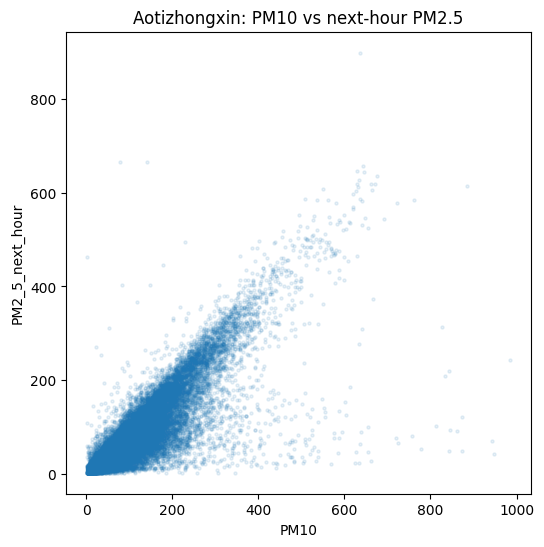

Aotizhongxin correlation (PM10 vs next-hour PM2.5): 0.844

Target distribution summary
count    360954.000000
mean         78.043979
std          77.777930
min           2.000000
25%          21.000000
50%          55.000000
75%         108.000000
max         999.000000
Name: PM2_5_next_hour, dtype: float64
Skewness: 2.013


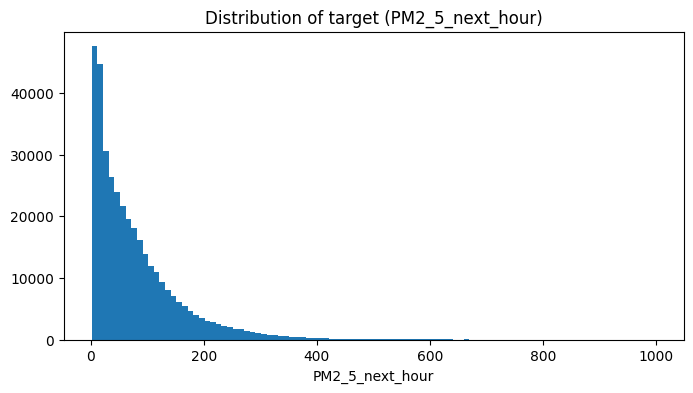

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/train.csv',
                  parse_dates=['observation_timestamp'])

# Duplicates check
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows: {n_duplicates}')
if n_duplicates > 0:
    df = df.drop_duplicates()
    print(f'Dropped duplicates. New shape: {df.shape}')

# Overall missing
missing_summary = df.isna().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
print('Overall missingness')
print(missing_summary)
print()

# Missing by station
missing_by_station = df.groupby('station').apply(
    lambda x: x.isna().mean() * 100, include_groups=False
).round(2)
print('Missingness by station')
print(missing_by_station)
print()

# Missing by month - for pollutants with the most gaps
def monthly_missing_pct(df, col):
    return (
        df[col].isna()
        .groupby(df['observation_timestamp'].dt.to_period('M'))
        .mean() * 100
    )

for col in ['CO', 'O3', 'NO2']:
    print(f'{col} monthly missing %')
    print(monthly_missing_pct(df, col).round(2))
    print()

# Train vs test date range (chronological gap check)
test_df = pd.read_csv('/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/test(1).csv',
                       parse_dates=['observation_timestamp'])
print('Train range:', df['observation_timestamp'].min(), '-', df['observation_timestamp'].max())
print('Test range:', test_df['observation_timestamp'].min(), '-', test_df['observation_timestamp'].max())
print('Test columns:', test_df.columns.tolist())
print()

# Correlation of each available predictor with the target
# Check what actually correlates
numeric_cols = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
correlations = df[numeric_cols + ['PM2_5_next_hour']].corr()['PM2_5_next_hour'].drop('PM2_5_next_hour')
print('Correlation of each predictor with PM2_5_next_hour')
print(correlations.sort_values(ascending=False).round(3))
print()

# Scatter of strongest available predictor vs target, one station
station_name = 'Aotizhongxin'
best_col = correlations.abs().idxmax()  # whichever predictor correlates most strongly
sub = df[df['station'] == station_name].dropna(subset=[best_col, 'PM2_5_next_hour'])

plt.figure(figsize=(6, 6))
plt.scatter(sub[best_col], sub['PM2_5_next_hour'], alpha=0.1, s=5)
plt.xlabel(best_col)
plt.ylabel('PM2_5_next_hour')
plt.title(f'{station_name}: {best_col} vs next-hour PM2.5')
plt.show()

print(f'{station_name} correlation ({best_col} vs next-hour PM2.5): {sub[best_col].corr(sub["PM2_5_next_hour"]):.3f}')
print()

# Target distribution
print('Target distribution summary')
print(df['PM2_5_next_hour'].describe())
print('Skewness:', round(df['PM2_5_next_hour'].skew(), 3))

plt.figure(figsize=(8, 4))
plt.hist(df['PM2_5_next_hour'].dropna(), bins=100)
plt.xlabel('PM2_5_next_hour')
plt.title('Distribution of target (PM2_5_next_hour)')
plt.show()

In [3]:
import numpy as np
# Check for impossible values
numeric_check_cols = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 
                      'PRES', 'RAIN', 'WSPM', 'PM2_5_next_hour']
for col in numeric_check_cols:
    n_negative = (df[col] < 0).sum()
    if n_negative > 0:
        print(f'{col}: {n_negative} negative values found')

# Create time features
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Prepare text/category columns
df['station'] = df['station'].astype('category')
df['wd'] = df['wd'].astype('category')

# Handle missing values (safe to re-run)
if 'Missing' not in df['wd'].cat.categories:
    df['wd'] = df['wd'].cat.add_categories('Missing')
df['wd'] = df['wd'].fillna('Missing')

# Test log-transforming the target to address its skew (skew = 2.013)
df['log_PM2_5_next_hour'] = np.log1p(df['PM2_5_next_hour'])
print('Skewness before log transform:', round(df['PM2_5_next_hour'].skew(), 3))
print('Skewness after log transform:', round(df['log_PM2_5_next_hour'].skew(), 3))

# Choose the columns we will use for the model
feature_cols = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'station', 'wd'
]
target_col = 'PM2_5_next_hour'
log_target_col = 'log_PM2_5_next_hour'

print('Model-ready dataframe shape:', df.shape)
print('Features:', feature_cols)
print(df[feature_cols + [target_col, log_target_col]].dtypes)

Skewness before log transform: 2.013
Skewness after log transform: -0.333
Model-ready dataframe shape: (360954, 24)
Features: ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'station', 'wd']
PM10                    float64
SO2                     float64
NO2                     float64
CO                      float64
O3                      float64
TEMP                    float64
PRES                    float64
DEWP                    float64
RAIN                    float64
WSPM                    float64
hour_sin                float64
hour_cos                float64
month_sin               float64
month_cos               float64
station                category
wd                     category
PM2_5_next_hour         float64
log_PM2_5_next_hour     float64
dtype: object


In [4]:
import numpy as np

# Apply the same preprocessing to test_df
test_df['hour_sin'] = np.sin(2 * np.pi * test_df['hour'] / 24)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['hour'] / 24)
test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)

test_df['station'] = test_df['station'].astype('category')
test_df['wd'] = test_df['wd'].astype('category')

if 'Missing' not in test_df['wd'].cat.categories:
    test_df['wd'] = test_df['wd'].cat.add_categories('Missing')
test_df['wd'] = test_df['wd'].fillna('Missing')

# Align station/wd categories between train and test
all_stations = sorted(set(df['station'].cat.categories) | set(test_df['station'].cat.categories))
all_wd = sorted(set(df['wd'].cat.categories) | set(test_df['wd'].cat.categories))

df['station'] = df['station'].cat.set_categories(all_stations)
test_df['station'] = test_df['station'].cat.set_categories(all_stations)
df['wd'] = df['wd'].cat.set_categories(all_wd)
test_df['wd'] = test_df['wd'].cat.set_categories(all_wd)

print('Test set ready:', test_df[feature_cols].shape)

# Save cleaned datasets
df.to_csv('/kaggle/working/train_cleaned.csv', index=False)
test_df.to_csv('/kaggle/working/test_cleaned.csv', index=False)

Test set ready: (51063, 16)


In [5]:
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

TIMESTAMP = "observation_timestamp"
TARGET = "PM2_5_next_hour"

DEBUG = False

def tic():
    return time.time()

def toc(label, t0):
    print(f"[{label}] {time.time() - t0:.1f}s")

# ---------------------------------------------------------------------------
# 1. Load raw data
# ---------------------------------------------------------------------------
t0 = tic()
train_raw = pd.read_csv(
    "/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/train.csv",
    parse_dates=[TIMESTAMP],
)
test_raw = pd.read_csv(
    "/kaggle/input/competitions/inter-uni-datathon-stream-2-beijing-multi-site-air-quality/test(1).csv",
    parse_dates=[TIMESTAMP],
)
toc("load data", t0)

if DEBUG:
    keep = train_raw["station"].unique()[:2]
    train_raw = train_raw[train_raw["station"].isin(keep)].copy()
    test_raw = test_raw[test_raw["station"].isin(keep)].copy()

# ---------------------------------------------------------------------------
# 2. Leakage-safe missing-value handling
#
# IMPORTANT:
# - No interpolation that looks forward in time.
# - No validation/test medians are used to fill earlier rows.
# - For a chronological validation split, fallback medians are learned only
#   from the earlier training portion.
# - Within a sequence, short gaps may use the last observed value (ffill).
# ---------------------------------------------------------------------------
numeric_cols = [
    c for c in ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
    if c in train_raw.columns
]

def clean_with_reference(df, reference_df=None):
    df = df.sort_values(["station", TIMESTAMP]).reset_index(drop=True).copy()
    reference_df = df if reference_df is None else reference_df

    # Fallback values are learned from reference data only.
    station_medians = reference_df.groupby("station")[numeric_cols].median()
    global_medians = reference_df[numeric_cols].median()

    for col in numeric_cols:
        # Only information at or before the current row is used.
        df[col] = df.groupby("station")[col].ffill(limit=6)

        # Then use medians learned from the permitted reference period.
        df[col] = df[col].fillna(
            df["station"].map(station_medians[col])
        ).fillna(global_medians[col])

    if "wd" in df.columns:
        station_modes = (
            reference_df.groupby("station")["wd"]
            .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else "N")
        )
        df["wd"] = df.groupby("station")["wd"].ffill(limit=6)
        df["wd"] = df["wd"].fillna(df["station"].map(station_modes)).fillna("N")

    return df

# Chronological validation split is defined BEFORE any learned imputation.
cutoff = train_raw[TIMESTAMP].quantile(0.8)
raw_train_part = train_raw[train_raw[TIMESTAMP] < cutoff].copy()
raw_val_part = train_raw[train_raw[TIMESTAMP] >= cutoff].copy()

# Validation is cleaned using only information available from the training period
# plus past observations within validation itself.
train_part_clean = clean_with_reference(raw_train_part)
val_part_clean = clean_with_reference(raw_val_part, reference_df=raw_train_part)

# Final training data may use all training observations because there is no
# future holdout after this point. Test fallback values are still learned only
# from training data.
train_clean = clean_with_reference(train_raw)
test_clean = clean_with_reference(test_raw, reference_df=train_raw)

print("Leakage-safe cleaning complete.")
print("Train rows:", len(train_clean), "| Test rows:", len(test_clean))

# ---------------------------------------------------------------------------
# 3. Feature engineering
#
# All temporal features are strictly past-looking:
# lags use shift(l), rolling windows use shift(1), and historical hour
# averages use only observations earlier than the current timestamp.
#
# The function may receive train + validation/test together because every
# temporal operation is causal. No target column is used to construct features.
# ---------------------------------------------------------------------------
def build_features(df):
    df = df.copy()
    df = df.sort_values(["station", TIMESTAMP]).reset_index(drop=True)

    wd_cardinal = {
        "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5, "E": 90, "ESE": 112.5,
        "SE": 135, "SSE": 157.5, "S": 180, "SSW": 202.5, "SW": 225,
        "WSW": 247.5, "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
    }
    if "wd" in df.columns:
        wd_deg = df["wd"].astype(str).str.strip().str.upper().map(wd_cardinal)
        wspm = df["WSPM"] if "WSPM" in df.columns else 1.0
        df["wind_u"] = -wspm * np.sin(np.radians(wd_deg))
        df["wind_v"] = -wspm * np.cos(np.radians(wd_deg))

    hour = df[TIMESTAMP].dt.hour
    month = df[TIMESTAMP].dt.month
    dow = df[TIMESTAMP].dt.dayofweek
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    df["sin_month"] = np.sin(2 * np.pi * (month - 1) / 12.0)
    df["cos_month"] = np.cos(2 * np.pi * (month - 1) / 12.0)
    df["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    df["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)

    if "PM10" in df.columns and "CO" in df.columns:
        df["pm10_co_ratio"] = df["PM10"] / (df["CO"] + 1e-3)
    if "NO2" in df.columns and "SO2" in df.columns:
        df["no2_so2_ratio"] = df["NO2"] / (df["SO2"] + 1e-3)
    if "CO" in df.columns and "NO2" in df.columns:
        df["co_no2_ratio"] = df["CO"] / (df["NO2"] + 1e-3)
    if "TEMP" in df.columns and "DEWP" in df.columns:
        df["temp_dewp_gap"] = df["TEMP"] - df["DEWP"]
    if "wind_u" in df.columns and "PM10" in df.columns:
        df["wind_u_pm10"] = df["wind_u"] * df["PM10"]
        df["wind_v_pm10"] = df["wind_v"] * df["PM10"]
    if "WSPM" in df.columns and "PM10" in df.columns:
        df["wspm_pm10_ratio"] = df["PM10"] / (df["WSPM"] + 1e-3)
    if "PRES" in df.columns and "TEMP" in df.columns:
        df["pres_temp_interact"] = df["PRES"] * df["TEMP"]

    pollutants = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM", "RAIN"]
    target_cols = [c for c in pollutants if c in df.columns]
    diff_cols = [c for c in ["PM10", "CO", "DEWP", "TEMP", "PRES"] if c in df.columns]
    zscore_cols = [c for c in ["PM10"] if c in df.columns]

    engineered_frames = []
    for station_id, group in df.groupby("station", observed=True):
        orig_ts = group[TIMESTAMP].copy()
        group = group.set_index(TIMESTAMP)
        full_idx = pd.date_range(group.index.min(), group.index.max(), freq="h")
        g = group.reindex(full_idx)

        new_cols = {}
        for col in target_cols:
            for l in [1, 2, 3, 6, 12, 24]:
                new_cols[f"{col}_lag_{l}"] = g[col].shift(l)

            shifted = g[col].shift(1)
            for window in ["3h", "6h", "12h", "24h"]:
                new_cols[f"{col}_roll_mean_{window}"] = shifted.rolling(window, min_periods=1).mean()
            new_cols[f"{col}_roll_std_24h"] = shifted.rolling("24h", min_periods=2).std()

        for col in diff_cols:
            # Difference at t uses x(t) and x(t-k); neither is the target.
            new_cols[f"{col}_diff_1h"] = g[col].diff(1)
            new_cols[f"{col}_diff_3h"] = g[col] - g[col].shift(3)

        for col in zscore_cols:
            shifted = g[col].shift(1)
            exp_mean = shifted.expanding(min_periods=5).mean()
            exp_std = shifted.expanding(min_periods=5).std()
            new_cols[f"{col.lower()}_zscore_vs_station"] = (
                (g[col] - exp_mean) / (exp_std + 1e-3)
            )

        for col in ["PM10", "CO"]:
            if col in g.columns:
                # For each hour-of-day, expanding() sees only prior rows because
                # the current row was shifted by one first.
                shifted_col = g[col].shift(1)
                hr = g.index.hour
                avg_col = pd.Series(index=g.index, dtype=float)
                for h in range(24):
                    mask = hr == h
                    avg_col.loc[mask] = shifted_col.loc[mask].expanding().mean()
                new_cols[f"station_hour_{col.lower()}_avg"] = avg_col

        g = pd.concat([g, pd.DataFrame(new_cols, index=g.index)], axis=1)
        restored = g.loc[g.index.isin(orig_ts)].reset_index()
        restored = restored.rename(columns={"index": TIMESTAMP})
        engineered_frames.append(restored)

    return pd.concat(engineered_frames, ignore_index=True)

# ---------------------------------------------------------------------------
# 4. Build validation features without future information
#
# Concatenate cleaned train/validation only. Since cleaning was causal and
# feature engineering is causal, validation rows can only see earlier rows.
# ---------------------------------------------------------------------------
t0 = tic()
validation_sequence = pd.concat(
    [train_part_clean, val_part_clean], ignore_index=True
)
validation_featured = build_features(validation_sequence)
toc("build validation features", t0)

train_df = validation_featured[
    validation_featured[TIMESTAMP] < cutoff
].copy()
val_part = validation_featured[
    validation_featured[TIMESTAMP] >= cutoff
].copy()

# ---------------------------------------------------------------------------
# 5. Build final train/test features
#
# Test rows can use earlier training/test observations, but never later test
# observations, because every temporal operation is causal.
# ---------------------------------------------------------------------------
t0 = tic()
final_sequence = pd.concat([train_clean, test_clean], ignore_index=True)
combined_featured = build_features(final_sequence)
toc("build final train/test features", t0)

test_ids = set(test_clean["id"].dropna())
train_df_final = combined_featured[
    ~combined_featured["id"].isin(test_ids)
].copy()
test_df = combined_featured[
    combined_featured["id"].isin(test_ids)
].copy()

train_df_final = train_df_final.dropna(subset=[TARGET]).reset_index(drop=True)
test_df = test_df.drop_duplicates(subset=["id"]).reset_index(drop=True)

# The validation model uses its own causally engineered split.
train_df = train_df.dropna(subset=[TARGET]).reset_index(drop=True)

ignore_cols = ["id", TIMESTAMP, TARGET, "year", "day", "log_PM2_5_next_hour"]
features = [c for c in train_df.columns if c not in ignore_cols]

cat_cols = [c for c in ["station", "station_type", "wd"] if c in features]

# Align category vocabularies across every split.
for col in cat_cols:
    cats = sorted(
        set(train_df[col].astype(str).dropna())
        | set(val_part[col].astype(str).dropna())
        | set(train_df_final[col].astype(str).dropna())
        | set(test_df[col].astype(str).dropna())
    )
    for frame in [train_df, val_part, train_df_final, test_df]:
        frame[col] = pd.Categorical(frame[col].astype(str), categories=cats)

for frame in [train_df, val_part, train_df_final, test_df]:
    for col in features:
        if col not in cat_cols and frame[col].dtype == "object":
            frame[col] = frame[col].astype(str).str.upper().eq("TRUE").astype("int8")

train_df_final.to_csv("train_cleaned_with_features.csv", index=False)
print(f"\nTotal features: {len(features)}")

# ---------------------------------------------------------------------------
# 6. Time-based validation
# ---------------------------------------------------------------------------
X_train, y_train = train_df[features], train_df[TARGET]
X_val, y_val = val_part[features], val_part[TARGET]

print(f"Train: {len(X_train):,} rows | Validation: {len(X_val):,} rows")
print(val_part["station"].value_counts())

# ---------------------------------------------------------------------------
# 7. Hyperparameter search
# ---------------------------------------------------------------------------
t0 = tic()
param_grid = [
    {"num_leaves": 31, "learning_rate": 0.05},
    {"num_leaves": 63, "learning_rate": 0.05},
    {"num_leaves": 63, "learning_rate": 0.1},
    {"num_leaves": 127, "learning_rate": 0.05},
]

best = None
best_rmse_search = float("inf")
for params in param_grid:
    model = lgb.LGBMRegressor(
        num_leaves=params["num_leaves"], learning_rate=params["learning_rate"],
        n_estimators=2000, random_state=42, n_jobs=-1, verbose=-1,
    )
    model.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    print(f"  num_leaves={params['num_leaves']} lr={params['learning_rate']} "
          f"-> RMSE {rmse:.4f} @ {model.best_iteration_} trees")
    if rmse < best_rmse_search:
        best_rmse_search = rmse
        best = {
            "num_leaves": params["num_leaves"],
            "learning_rate": params["learning_rate"],
            "n_estimators": model.best_iteration_,
        }
toc("hyperparameter search", t0)
print(f"\nBest params: {best} | search RMSE: {best_rmse_search:.4f}")

# ---------------------------------------------------------------------------
# 8. Final validation models
# ---------------------------------------------------------------------------
t0 = tic()
lgb_model = lgb.LGBMRegressor(
    num_leaves=int(best["num_leaves"]), learning_rate=best["learning_rate"],
    n_estimators=int(best["n_estimators"]), random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(X_train, y_train)
lgb_val_preds = lgb_model.predict(X_val)
lgb_rmse = mean_squared_error(y_val, lgb_val_preds) ** 0.5
lgb_mae = mean_absolute_error(y_val, lgb_val_preds)
toc("final LightGBM fit", t0)
print(f"\nLightGBM validation RMSE: {lgb_rmse:.4f} | MAE: {lgb_mae:.4f}")
print(f"Median abs error: {np.median(np.abs(y_val - lgb_val_preds)):.4f}")
print(f"90th percentile abs error: {np.quantile(np.abs(y_val - lgb_val_preds), 0.90):.4f}")

t0 = tic()
xgb_model = XGBRegressor(
    n_estimators=800, learning_rate=0.03, max_depth=6, random_state=42,
    n_jobs=-1, enable_categorical=True, tree_method="hist",
    early_stopping_rounds=50, eval_metric="rmse",
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_val_preds = xgb_model.predict(
    X_val, iteration_range=(0, xgb_model.best_iteration + 1)
)
xgb_rmse = mean_squared_error(y_val, xgb_val_preds) ** 0.5
toc("XGBoost fit", t0)
print(f"XGBoost validation RMSE: {xgb_rmse:.4f} @ {xgb_model.best_iteration} trees")

# ---------------------------------------------------------------------------
# 9. Blend
# ---------------------------------------------------------------------------
best_rmse = float("inf")
best_w = 1.0
for w in np.arange(0.0, 1.01, 0.1):
    blend = w * lgb_val_preds + (1 - w) * xgb_val_preds
    rmse = mean_squared_error(y_val, blend) ** 0.5
    if rmse < best_rmse:
        best_rmse = rmse
        best_w = w

print(f"Best blend weight (LightGBM): {best_w:.1f} | Blended validation RMSE: {best_rmse:.4f}")

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=False)
print("\nTop 20 features:")
print(importance.head(20).to_string(index=False))

# ---------------------------------------------------------------------------
# 10. Retrain on ALL training data and predict test
# ---------------------------------------------------------------------------
t0 = tic()
lgb_final = lgb.LGBMRegressor(
    num_leaves=int(best["num_leaves"]), learning_rate=best["learning_rate"],
    n_estimators=int(best["n_estimators"]), random_state=42, n_jobs=-1, verbose=-1,
)
lgb_final.fit(train_df_final[features], train_df_final[TARGET])

if best_w < 1.0:
    xgb_final = XGBRegressor(
        n_estimators=xgb_model.best_iteration + 1, learning_rate=0.03, max_depth=6,
        random_state=42, n_jobs=-1, enable_categorical=True, tree_method="hist",
    )
    xgb_final.fit(train_df_final[features], train_df_final[TARGET])
    lgb_test_preds = lgb_final.predict(test_df[features])
    xgb_test_preds = xgb_final.predict(test_df[features])
    final_preds = np.clip(
        best_w * lgb_test_preds + (1 - best_w) * xgb_test_preds, 0, None
    )
else:
    final_preds = np.clip(lgb_final.predict(test_df[features]), 0, None)

toc("retrain on full data + predict", t0)

# ---------------------------------------------------------------------------
# 11. Export submission
# ---------------------------------------------------------------------------
submission = test_clean[["id"]].merge(
    pd.DataFrame({"id": test_df["id"], "PM2_5_next_hour": final_preds}),
    on="id", how="left"
)

submission["PM2_5_next_hour"] = submission["PM2_5_next_hour"].fillna(
    train_df_final[TARGET].mean()
)

submission.to_csv("submission.csv", index=False)
print(f"\nSubmission saved. {len(submission):,} rows.")


[load data] 1.0s
Leakage-safe cleaning complete.
Train rows: 360954 | Test rows: 51063
[build validation features] 3.5s
[build final train/test features] 3.9s

Total features: 153
Train: 288,762 rows | Validation: 72,192 rows
station
Wanliu           6075
Nongzhanguan     6075
Gucheng          6068
Changping        6059
Tiantan          6054
Guanyuan         6044
Huairou          6028
Dingling         6025
Aotizhongxin     5999
Wanshouxigong    5963
Shunyi           5935
Dongsi           5867
Name: count, dtype: int64
  num_leaves=31 lr=0.05 -> RMSE 25.1829 @ 716 trees
  num_leaves=63 lr=0.05 -> RMSE 25.0299 @ 541 trees
  num_leaves=63 lr=0.1 -> RMSE 25.1450 @ 346 trees
  num_leaves=127 lr=0.05 -> RMSE 25.1725 @ 321 trees
[hyperparameter search] 220.0s

Best params: {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 541} | search RMSE: 25.0299
[final LightGBM fit] 56.6s

LightGBM validation RMSE: 25.0299 | MAE: 13.5368
Median abs error: 7.8412
90th percentile abs error: 30.1362
